11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8952 - loss: 0.3439 - val_accuracy: 0.9780 - val_loss: 0.0725
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9664 - loss: 0.1151 - val_accuracy: 0.9865 - val_loss: 0.0494
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9759 - loss: 0.0813 - val_accuracy: 0.9877 - val_loss: 0.0423
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9803 - loss: 0.0649 - val_accuracy: 0.9885 - val_loss: 0.0397
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9827 - loss: 0.0561 - val_accuracy: 0.9907 - val_loss: 0.0342
Test Accuracy: 0.9905
Macro Precision: 0.9904
Macro Recall: 0.9904


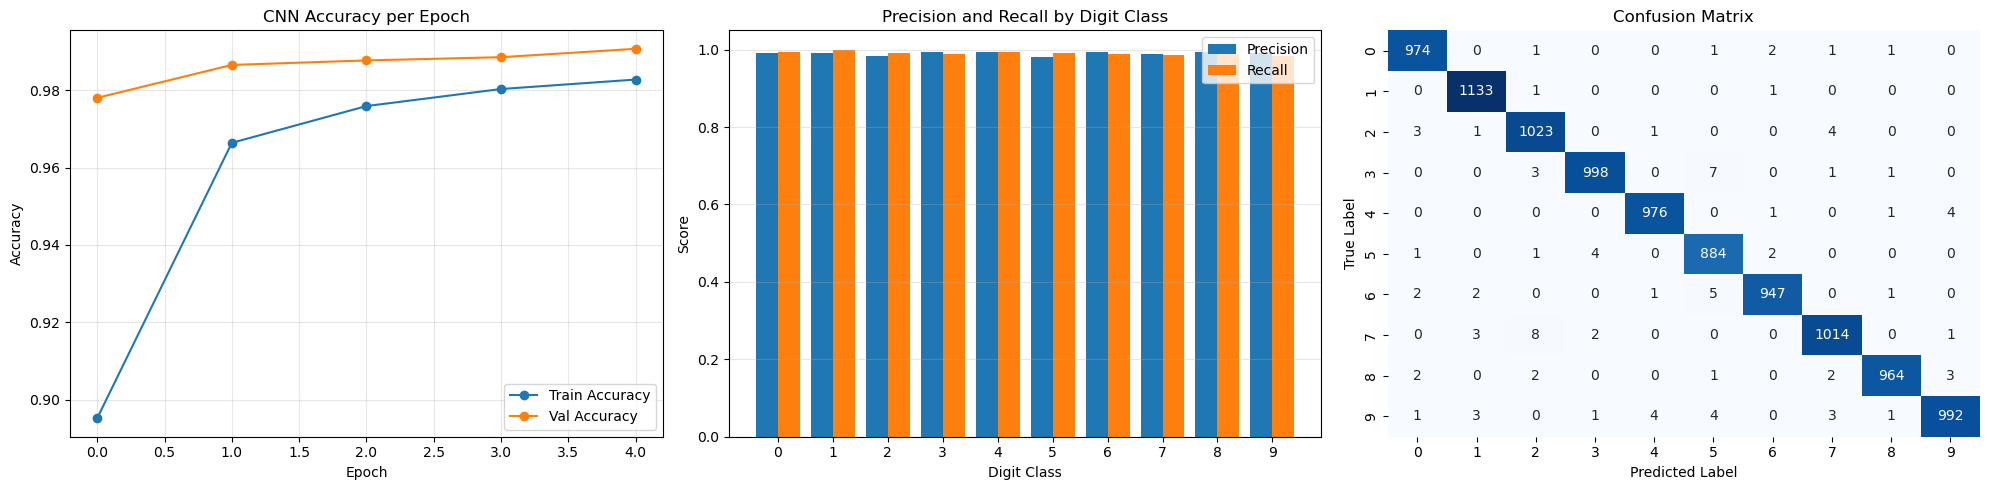

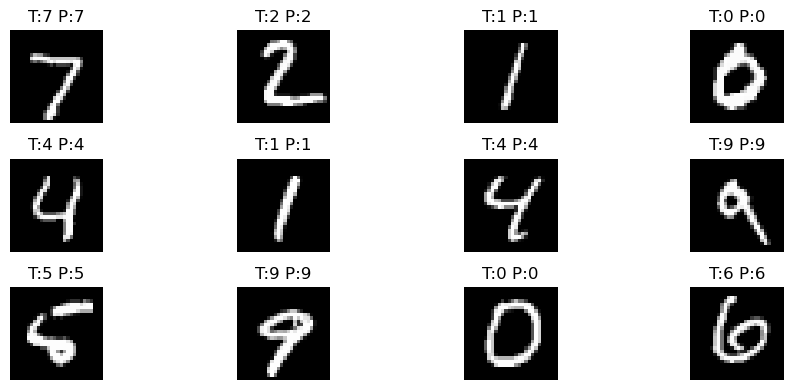

In [1]:
# Optional: run once if packages are missing in this kernel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1) Fetch MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2) Preprocess
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# 3) Build a small CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 4) Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 5) Evaluate and predict
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(f'Test Accuracy: {test_acc:.4f}')

# 6) Metrics: precision, recall (per class and macro)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(10), zero_division=0
)
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
print(f'Macro Precision: {macro_precision:.4f}')
print(f'Macro Recall: {macro_recall:.4f}')

# 7) Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 8) Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot A: Training vs Validation Accuracy
axes[0].plot(history.history['accuracy'], marker='o', label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], marker='o', label='Val Accuracy')
axes[0].set_title('CNN Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot B: Precision and Recall per class
digits = np.arange(10)
bar_w = 0.4
axes[1].bar(digits - bar_w/2, precision, width=bar_w, label='Precision')
axes[1].bar(digits + bar_w/2, recall, width=bar_w, label='Recall')
axes[1].set_title('Precision and Recall by Digit Class')
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Score')
axes[1].set_xticks(digits)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

# Plot C: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 9) Optional: show first 12 predictions
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f'T:{y_test[i]} P:{y_pred[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()